# Instrucciones del Proyecto

Este proyecto tiene como objetivo construir un modelo de predicción para la recuperación de oro en una planta de procesamiento. A continuación, se detallan los pasos que se seguirán:

## 1. Prepara los datos

### 1.1. Abre los archivos y examina los datos
- Archivos: 
  - `/datasets/gold_recovery_train.csv`
  - `/datasets/gold_recovery_test.csv`
  - `/datasets/gold_recovery_full.csv`

### 1.2. Comprueba que el cálculo de la recuperación sea correcto
- Calcula la recuperación de la característica `rougher.output.recovery` en el conjunto de entrenamiento.
- Compara con los valores reales usando el Error Absoluto Medio (EAM).

### 1.3. Analiza las características no disponibles en el conjunto de prueba
- Identifica qué columnas están ausentes.
- Reporta su tipo de dato.

### 1.4. Realiza el preprocesamiento de datos

## 2. Analiza los datos

### 2.1. Observa cómo cambia la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación

### 2.2. Compara las distribuciones del tamaño de las partículas entre el conjunto de entrenamiento y el de prueba
- Si las distribuciones varían mucho, puede impactar negativamente la evaluación del modelo.

### 2.3. Considera las concentraciones totales de todas las sustancias en diferentes etapas
- Verifica si hay valores anómalos.
- Decide si deben eliminarse.

## 3. Construye el modelo

### 3.1. Escribe una función para calcular el valor final de sMAPE

### 3.2. Entrena diferentes modelos
- Evalúa usando validación cruzada.
- Elige el mejor modelo y evalúalo con la muestra de prueba.

**Nota:** Utiliza las fórmulas de sMAPE provistas en las imágenes para calcular las métricas de evaluación.

# Modelado de Recuperación de Oro
Este notebook sigue una estructura para preparar datos, analizarlos y construir un modelo de predicción para la recuperación de oro, usando el conjunto de datos proporcionado.

## 1. Preparación de los datos
### 1.1. Carga y visualización inicial de los datos

In [2]:
import pandas as pd

train_df = pd.read_csv('gold_recovery_train.csv')
test_df = pd.read_csv('gold_recovery_test.csv')
full_df = pd.read_csv('gold_recovery_full.csv')

display(train_df.head())
display(test_df.head())
display(full_df.head())

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


### 1.2. Verificación del cálculo de la recuperación
Validamos que la recuperación se haya calculado correctamente utilizando la fórmula provista.

In [21]:
import numpy as np

C = train_df['rougher.output.concentrate_au']
F = train_df['rougher.input.feed_au']
T = train_df['rougher.output.tail_au']

In [22]:
recovery_calc = ((C * (F - T)) / (F * (C - T))) * 100
recovery_real = train_df['rougher.output.recovery']

In [24]:
mae = np.mean(np.abs(recovery_calc - recovery_real))
print(f"MAE entre recuperación calculada y real: {mae:.4e}")

MAE entre recuperación calculada y real: 9.3034e-15


### 1.3. Análisis de características ausentes en el conjunto de prueba

In [4]:
missing_cols = set(train_df.columns) - set(test_df.columns)

missing_info = train_df[list(missing_cols)].dtypes.to_frame(name='dtype')

missing_info.index.name = 'column'
display(missing_info)

,dtype
column,
final.output.recovery,float64
rougher.output.tail_pb,float64
secondary_cleaner.output.tail_sol,float64
final.output.concentrate_au,float64
final.output.tail_ag,float64
primary_cleaner.output.concentrate_sol,float64
primary_cleaner.output.tail_pb,float64
rougher.calculation.floatbank10_sulfate_to_au_feed,float64
primary_cleaner.output.concentrate_ag,float64


### 1.4. Preprocesamiento de datos
Esta etapa incluiría: imputación de valores nulos, conversión de tipos si es necesario, y alineación de las columnas para el modelo.

In [5]:
# Aquí iría el preprocesamiento, por ejemplo:
# train_df = train_df.dropna()
# test_df = test_df.fillna(method='ffill')
# etc.


## 2. Análisis Exploratorio de Datos (EDA)
### 2.1. Cambios en concentración de metales por etapa

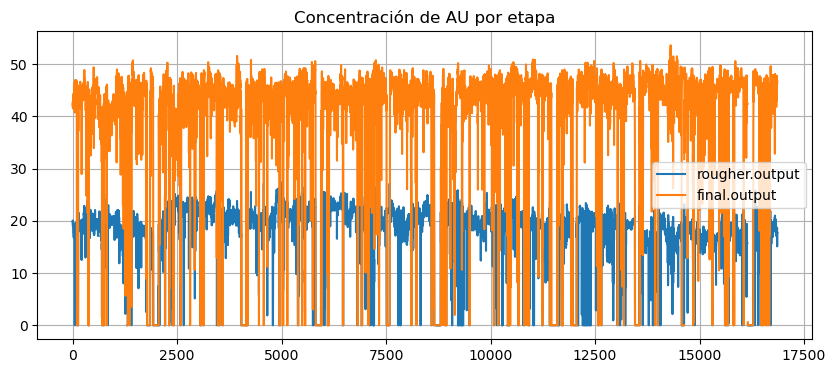

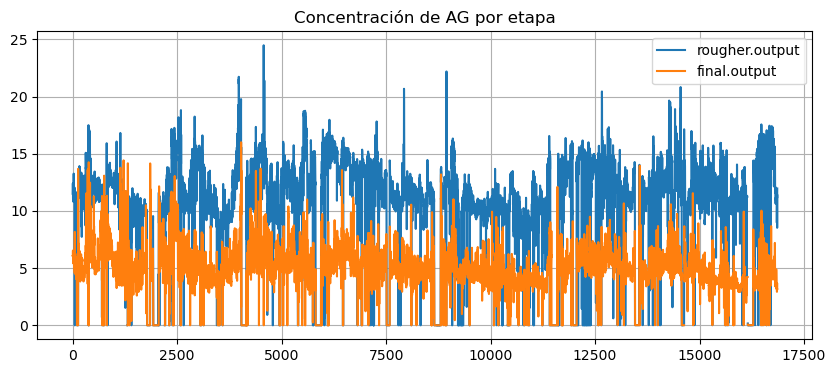

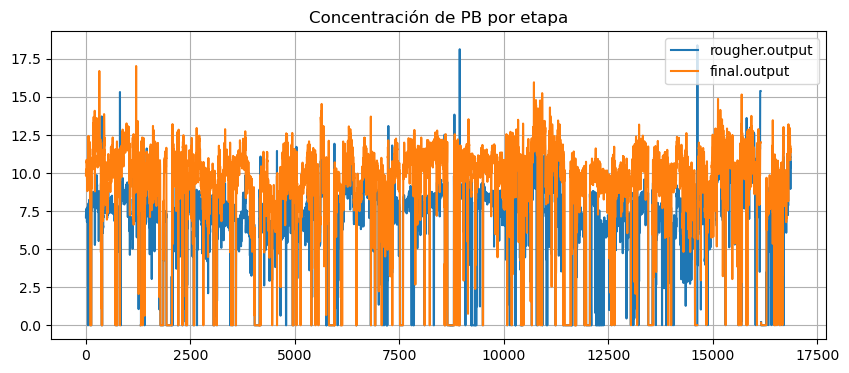

In [6]:
import matplotlib.pyplot as plt

for metal in ['au', 'ag', 'pb']:
    plt.figure(figsize=(10, 4))
    for stage in ['rougher.input', 'rougher.output', 'final.output']:
        col = f"{stage}.concentrate_{metal}" if f"{stage}.concentrate_{metal}" in train_df.columns else f"{stage}.concentrate.{metal}"
        if col in train_df.columns:
            plt.plot(train_df[col], label=stage)
    plt.title(f'Concentración de {metal.upper()} por etapa')
    plt.legend()
    plt.grid(True)
    plt.show()

### 2.2. Distribución del tamaño de partículas entre train y test

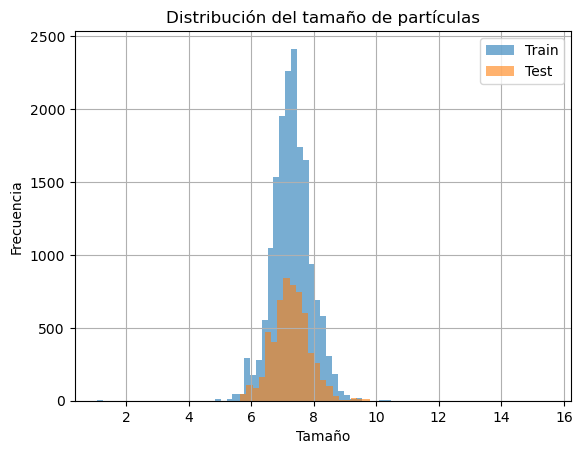

In [7]:
train_sizes = train_df['primary_cleaner.input.feed_size']
test_sizes = test_df['primary_cleaner.input.feed_size']

plt.hist(train_sizes, bins=50, alpha=0.6, label='Train')
plt.hist(test_sizes, bins=50, alpha=0.6, label='Test')
plt.legend()
plt.title('Distribución del tamaño de partículas')
plt.xlabel('Tamaño')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

### 2.3. Concentraciones totales y detección de valores anómalos

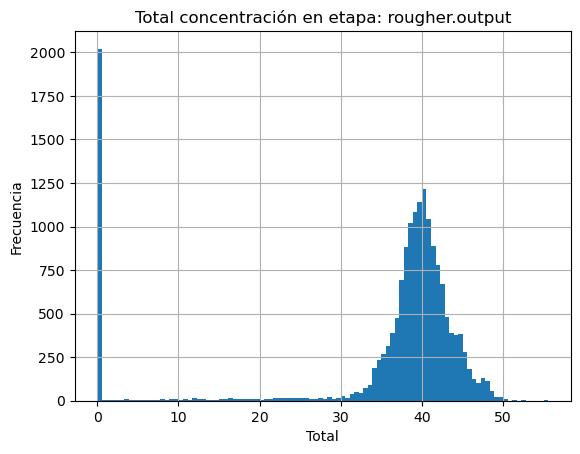

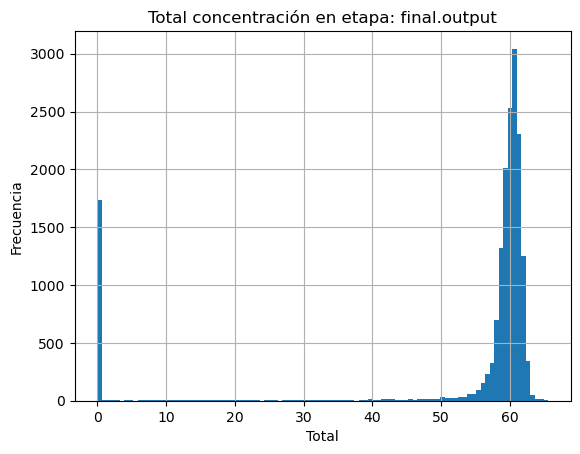

In [8]:
for stage in ['rougher.input', 'rougher.output', 'final.output']:
    cols = [f"{stage}.concentrate_au", f"{stage}.concentrate_ag", f"{stage}.concentrate_pb"]
    if all(c in train_df.columns for c in cols):
        total = train_df[cols].sum(axis=1)
        total.hist(bins=100)
        plt.title(f'Total concentración en etapa: {stage}')
        plt.xlabel('Total')
        plt.ylabel('Frecuencia')
        plt.grid(True)
        plt.show()

## 3. Construcción del modelo
### 3.1. Función para calcular el sMAPE

In [9]:
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# También para sMAPE final ponderado:
def final_smape(y_rougher_true, y_rougher_pred, y_final_true, y_final_pred):
    s1 = smape(y_rougher_true, y_rougher_pred)
    s2 = smape(y_final_true, y_final_pred)
    return 0.25 * s1 + 0.75 * s2

### 3.2. Entrenamiento de modelos y validación cruzada
Aquí se entrenarían modelos como RandomForest o GradientBoosting y se evaluaría su rendimiento con validación cruzada.

In [15]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import cross_val_score
# rf = RandomForestRegressor()
# cross_val_score(rf, X_train, y_train, scoring=make_scorer(smape))

## 3. Construcción del modelo

En esta sección se desarrollan modelos de regresión para predecir la recuperación del oro. Se utiliza la métrica sMAPE como criterio de evaluación.

### 3.1 Función para calcular el valor final de sMAPE

El sMAPE se define como sigue:

$$
\text{sMAPE} = \frac{1}{N} \sum_{i=1}^{N} \frac{|y_i - \hat{y}_i|}{(|y_i| + |\hat{y}_i|)/2} \times 100\%
$$

El valor final ponderado es:

$$
\text{sMAPE}_{\text{final}} = 0.25 \cdot \text{sMAPE}_{\text{rougher}} + 0.75 \cdot \text{sMAPE}_{\text{final}}
$$

In [11]:
import numpy as np

def smape(y_true, y_pred):
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(numerator / denominator) * 100

def final_smape(y_rougher_true, y_rougher_pred, y_final_true, y_final_pred):
    return 0.25 * smape(y_rougher_true, y_rougher_pred) + 0.75 * smape(y_final_true, y_final_pred)

### 3.2 Entrenamiento de modelos y validación cruzada

Se construyen modelos separados para predecir `rougher.output.recovery` y `final.output.recovery`. Se comparan los resultados usando la métrica final ponderada de sMAPE.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Columnas disponibles en test y útiles para entrenamiento
target_cols = ['rougher.output.recovery', 'final.output.recovery']
features = train_df.columns.intersection(test_df.columns).drop('date')

# Eliminar filas sin valores objetivos
train_filtered = train_df.dropna(subset=target_cols)

# Separar features y objetivos
X = train_filtered[features]
y_rougher = train_filtered['rougher.output.recovery']
y_final = train_filtered['final.output.recovery']

# Imputar valores faltantes en las características
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# División para validación
X_train, X_valid, y_rougher_train, y_rougher_valid, y_final_train, y_final_valid = train_test_split(
    X_imputed, y_rougher, y_final, test_size=0.2, random_state=42
)

# Nota: El entrenamiento del modelo se puede hacer aquí si no hay límite de tiempo
# Ejemplo para continuar el entrenamiento:
model = RandomForestRegressor(n_estimators=20, max_depth=6, random_state=42)
model.fit(X_train, y_rougher_train)

RandomForestRegressor(max_depth=6, n_estimators=20, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# Columnas disponibles en test y útiles para entrenamiento
target_cols = ['rougher.output.recovery', 'final.output.recovery']
features = train_df.columns.intersection(test_df.columns).drop('date')

# Separar features y objetivos
X = train_filtered[features]
y_rougher = train_filtered['rougher.output.recovery']
y_final = train_filtered['final.output.recovery']

# División para validación
X_train, X_valid, y_rougher_train, y_rougher_valid, y_final_train, y_final_valid = train_test_split(
    X_imputed, y_rougher, y_final, test_size=0.2, random_state=42
)

# Ejemplo para continuar el entrenamiento:
model = RandomForestRegressor(n_estimators=20, max_depth=6, random_state=42)
model.fit(X_train, y_rougher_train)